# 🌳 Sessão 11 — U-Net para Segmentação de Copas

> **Objetivo:** atacar uma tarefa **estruturalmente impossível** para modelos paramétricos: segmentação semântica pixel-a-pixel de copas individuais em chips raster multi-banda. A U-Net (Ronneberger et al., 2015) é o padrão moderno para predição densa, e esta é a primeira sessão em que o deep learning vence **sem competição justa** — porque não existe equivalente paramétrico para gerar máscaras pixel-a-pixel.

---

## 📑 Sumário

1. [Fundamentação Teórica](#1-fundamentação-teórica)
2. [Geração do Dataset Sintético](#2-geração-do-dataset-sintético)
3. [Exploração Visual](#3-exploração-visual)
4. [Baseline: Threshold de NDVI](#4-baseline-threshold-de-ndvi)
5. [U-Net End-to-End](#5-u-net-end-to-end)
6. [Comparação Visual e Estatística](#6-comparação-visual-e-estatística)
7. [Análise por Chip](#7-análise-por-chip)
8. [Síntese: Onde o Deep Learning É Insubstituível](#8-síntese-onde-o-deep-learning-é-insubstituível)

## 1. Fundamentação Teórica

### Segmentação semântica

Segmentação semântica é a tarefa de atribuir um rótulo de classe a **cada pixel** de uma imagem. Diferentemente de classificação (um rótulo por imagem) ou detecção (caixas delimitadoras), aqui a saída tem a mesma resolução espacial da entrada. Em sensoriamento remoto florestal, esta tarefa é fundamental para:

- **Mapeamento de copas individuais** em ortomosaicos drone
- **Delineamento de talhões** em produtos Sentinel-2
- **Detecção de áreas queimadas** (active fires)
- **Monitoramento de desmatamento** (mudança classe-a-classe)

### Arquitetura U-Net

Ronneberger et al. (2015) propuseram a U-Net para imagens biomédicas. A intuição central é simples: um encoder convolucional captura **contexto** (o que tem na vizinhança), e um decoder com upsampling reconstrói a **localização** dos objetos. **Skip connections** entre níveis equivalentes do encoder e do decoder garantem que detalhes espaciais finos não sejam perdidos no caminho.

$$\mathcal{L}_{\text{BCE-Dice}} = \alpha \cdot \text{BCE}(p, y) + (1 - \alpha) \cdot (1 - \text{Dice}(p, y))$$

A perda combinada BCE + Dice é o padrão moderno (Milletari et al., 2016): BCE provê gradientes pixel-a-pixel estáveis, enquanto Dice foca explicitamente na **sobreposição de regiões** — crítico quando a classe positiva é rara (copas ocupam ~7% dos pixels).

### Métricas de avaliação

| Métrica | Definição | Quando usar |
|---|---|---|
| **IoU (Jaccard)** | $\|A \cap B\| / \|A \cup B\|$ | Padrão para segmentação; penaliza erros de fronteira |
| **Dice** | $2 \|A \cap B\| / (\|A\| + \|B\|)$ | F1 pixel-a-pixel; mais permissivo que IoU |
| **Pixel Accuracy** | (TP+TN) / total | **Enganosa** em classes desbalanceadas |

### Por que não há baseline paramétrico justo?

Diferentemente das sessões 06-09, **não existe um modelo paramétrico clássico** que gere uma máscara pixel-a-pixel a partir de uma imagem multi-banda. A alternativa tradicional é o **threshold de índice espectral** (NDVI > t), mas ela:

1. Não usa contexto espacial (cada pixel é classificado isoladamente)
2. Falha em imagens com fundo verde (gramíneas vs copas têm NDVI próximo)
3. Não captura forma — não distingue copa de mato denso

Esta sessão demonstra empiricamente esses três limites.

## 2. Geração do Dataset Sintético

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from forestpy.data.canopy_chips import generate_segmentation_chips
from forestpy.data.chips import compute_ndvi
from forestpy.ml.cnn import UNet, UNetTrainer
from forestpy.ml.metrics import (
    iou_score, dice_score, pixel_accuracy, segmentation_report,
)
from forestpy.utils import set_seed, get_logger
from forestpy.viz.style import apply_forest_style
from forestpy.viz.diagnostics import plot_learning_curve
from forestpy.viz.segmentation import (
    plot_segmentation_triptych, plot_segmentation_panel,
)

set_seed(42)
apply_forest_style()
log = get_logger('sessao_11')

# 120 chips de 64×64 com 3-10 copas elípticas cada
ds = generate_segmentation_chips(
    n_chips=120, chip_size=64,
    trees_range=(3, 10), seed=42,
)
log.info(f'Dataset: {ds.X.shape[0]} chips de {ds.X.shape[2]}×{ds.X.shape[3]} pixels, '
         f'{ds.X.shape[1]} bandas')
log.info(f'Árvores por chip: min={min(ds.n_trees_per_chip)}, '
         f'max={max(ds.n_trees_per_chip)}, média={np.mean(ds.n_trees_per_chip):.1f}')
log.info(f'Fração média de copa por chip: {ds.Y.mean():.3f} ({ds.Y.mean()*100:.1f}%)')

[15:08:30] INFO     Dataset: 120 chips de 64×64 pixels, 4 bandas

           INFO     Árvores por chip: min=3, max=10, média=6.3

           INFO     Fração média de copa por chip: 0.065 (6.5%)

## 3. Exploração Visual

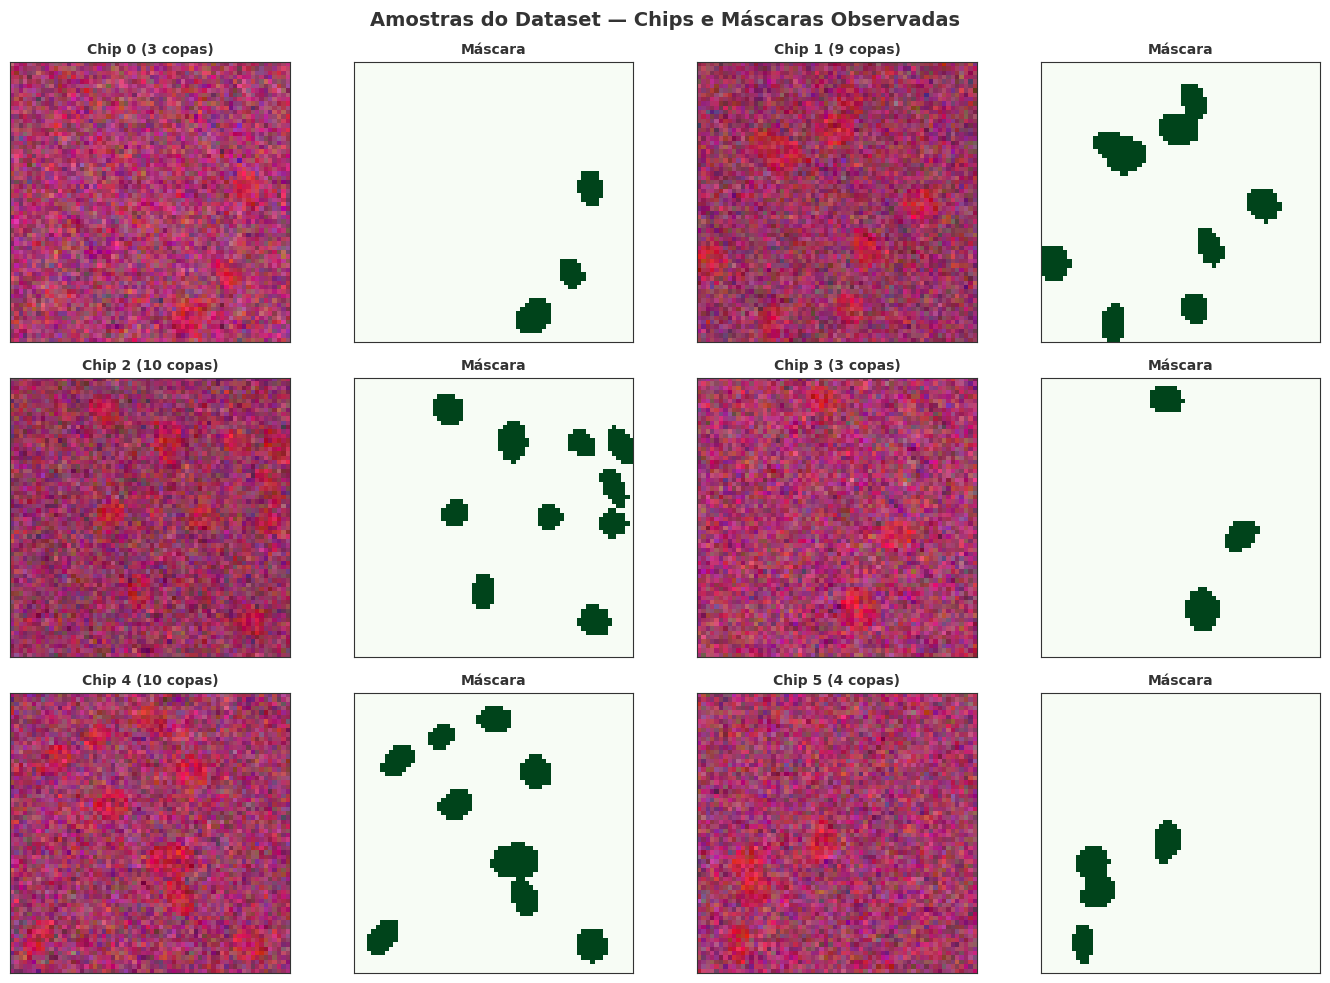

In [2]:
# Painel com 6 chips e suas máscaras observadas
fig_explore, axes = plt.subplots(3, 4, figsize=(14, 10))
for i, ax_pair_idx in enumerate(range(6)):
    chip = ds.X[i]
    mask = ds.Y[i]
    # Falsa-cor NIR-R-G (vegetação avermelhada)
    rgb = np.stack([chip[3], chip[0], chip[1]], axis=-1)
    rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-8)
    row, col_pair = i // 2, (i % 2) * 2
    axes[row, col_pair].imshow(rgb)
    axes[row, col_pair].set_title(f'Chip {i} ({ds.n_trees_per_chip[i]} copas)',
                                   fontsize=10)
    axes[row, col_pair+1].imshow(mask, cmap='Greens', vmin=0, vmax=1)
    axes[row, col_pair+1].set_title('Máscara', fontsize=10)
    for ax in [axes[row, col_pair], axes[row, col_pair+1]]:
        ax.set_xticks([]); ax.set_yticks([])

fig_explore.suptitle('Amostras do Dataset — Chips e Máscaras Observadas',
                     fontsize=14, fontweight='bold')
fig_explore.tight_layout()
fig_explore.savefig('../reports/figures/11_amostras_dataset.png')
plt.show()

**🔍 Observação:** copas e fundo são ambos vegetação — em falsa-cor NIR-R-G ambos ficam avermelhados. A separação visual depende de **textura espacial** (copas têm bordas e formato) e **sutis diferenças de tom**, não de cor isolada. Esta dificuldade é proposital: emula condições reais de ortomosaicos sobre pastagens degradadas com vegetação rasteira.

## 4. Baseline: Threshold de NDVI

A abordagem clássica pré-deep-learning para mapeamento de vegetação é o **threshold de NDVI**:

$$\text{NDVI} = \frac{\text{NIR} - \text{Red}}{\text{NIR} + \text{Red}}$$

Pixels com NDVI acima de um threshold são classificados como copa. Buscamos o threshold ótimo no treino e aplicamos ao teste — procedimento honesto que evita data leakage.

In [3]:
# Split 70/15/15
rng = np.random.default_rng(0)
idx = rng.permutation(len(ds.Y))
n_tr = int(0.7 * len(idx))
n_va = int(0.15 * len(idx))
tr, va, te = idx[:n_tr], idx[n_tr:n_tr+n_va], idx[n_tr+n_va:]
log.info(f'Treino: {len(tr)} | Validação: {len(va)} | Teste: {len(te)}')

# NDVI por chip
ndvi_tr = compute_ndvi(ds.X[tr])
ndvi_te = compute_ndvi(ds.X[te])

# Busca do melhor threshold no treino (grid)
thresholds_grid = np.arange(0.30, 0.80, 0.025)
ious_por_t = []
for t in thresholds_grid:
    pred = (ndvi_tr > t).astype(np.uint8)
    ious = [iou_score(ds.Y[tr][i], pred[i]) for i in range(len(tr))]
    ious_por_t.append(np.mean(ious))
ious_por_t = np.array(ious_por_t)
best_idx = ious_por_t.argmax()
best_t = thresholds_grid[best_idx]
log.info(f'Melhor threshold de NDVI (treino): {best_t:.3f} '
         f'(IoU treino = {ious_por_t[best_idx]:.4f})')

[15:10:38] INFO     Treino: 84 | Validação: 18 | Teste: 18

[15:10:39] INFO     Melhor threshold de NDVI (treino): 0.675 (IoU treino = 0.1950)

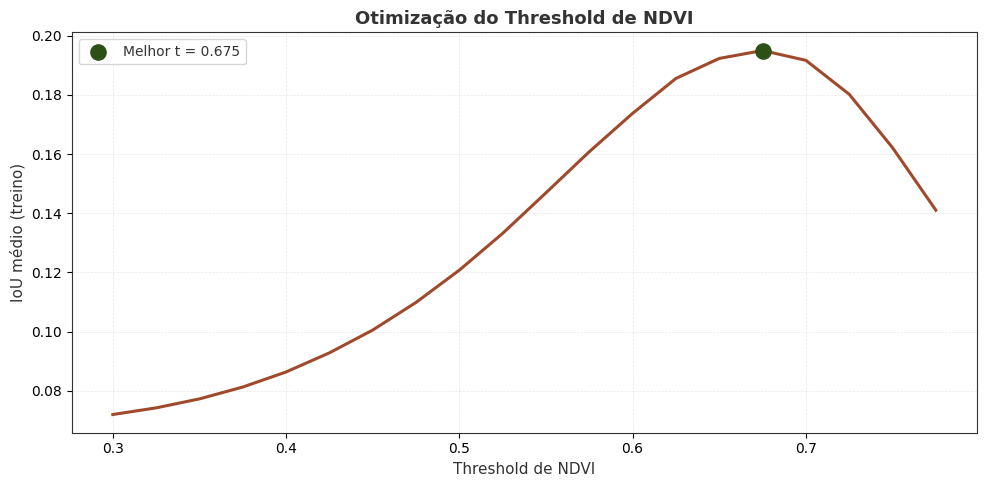

In [4]:
# Curva: IoU vs threshold
fig_ndvi, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds_grid, ious_por_t, lw=2.2, color='#a04a2c')
ax.scatter([best_t], [ious_por_t[best_idx]], color='#2d5016',
           s=120, zorder=5, label=f'Melhor t = {best_t:.3f}')
ax.set_xlabel('Threshold de NDVI')
ax.set_ylabel('IoU médio (treino)')
ax.set_title('Otimização do Threshold de NDVI', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
fig_ndvi.tight_layout()
fig_ndvi.savefig('../reports/figures/11_ndvi_threshold.png')
plt.show()

In [5]:
# Aplicação no teste
pred_ndvi_te = (ndvi_te > best_t).astype(np.uint8)
report_ndvi = segmentation_report(ds.Y[te], pred_ndvi_te)
log.info('Baseline NDVI no teste:')
for k, v in report_ndvi.items():
    log.info(f'  {k:12s} = {v:.4f}')

[15:10:52] INFO     Baseline NDVI no teste:

           INFO       iou          = 0.1882

           INFO       dice         = 0.3168

           INFO       pixel_acc    = 0.8734

## 5. U-Net End-to-End

Arquitetura: 2 níveis de pooling, 16 filtros base. Treino com BCE+Dice (50/50).

[15:11:00] INFO     U-Net: 117,825 parâmetros

[15:11:41] INFO     Treino: 50 épocas (melhor: 50)

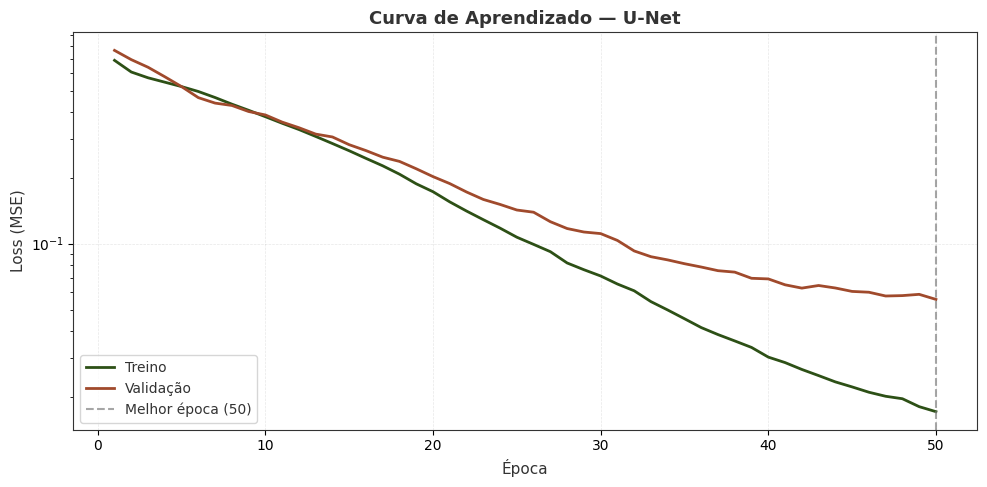

In [6]:
set_seed(42)
model = UNet(in_channels=4, out_channels=1, base_filters=16, chip_size=64)
log.info(f'U-Net: {model.count_parameters():,} parâmetros')

trainer = UNetTrainer(
    model, learning_rate=1e-3,
    weight_decay=1e-5, bce_weight=0.5,
)
hist = trainer.fit(
    ds.X[tr], ds.Y[tr], ds.X[va], ds.Y[va],
    epochs=50, batch_size=8, patience=12, verbose=False,
)
log.info(f'Treino: {len(hist.train_loss)} épocas (melhor: {hist.best_epoch})')

fig_lc = plot_learning_curve(
    hist.train_loss, hist.val_loss,
    best_epoch=hist.best_epoch,
    title='Curva de Aprendizado — U-Net',
)
fig_lc.savefig('../reports/figures/11_curva_aprendizado.png')
plt.show()

In [7]:
# Avaliação no teste
pred_unet_te = trainer.predict(ds.X[te], threshold=0.5)
report_unet = segmentation_report(ds.Y[te], pred_unet_te)
log.info('U-Net no teste:')
for k, v in report_unet.items():
    log.info(f'  {k:12s} = {v:.4f}')

[15:11:55] INFO     U-Net no teste:

           INFO       iou          = 0.8951

           INFO       dice         = 0.9446

           INFO       pixel_acc    = 0.9932

## 6. Comparação Visual e Estatística

In [8]:
# Tabela comparativa
comparativo = pd.DataFrame([
    {
        'Modelo': 'Threshold de NDVI', 'Parâmetros': 1,
        'Usa contexto espacial?': 'Não', **report_ndvi,
    },
    {
        'Modelo': 'U-Net', 'Parâmetros': model.count_parameters(),
        'Usa contexto espacial?': 'Sim', **report_unet,
    },
]).round(4)
comparativo.to_csv('../reports/tables/11_ndvi_vs_unet.csv', index=False)
comparativo

,Modelo,Parâmetros,Usa contexto espacial?,iou,dice,pixel_acc
0,Threshold de NDVI,1,Não,0.1882,0.3168,0.8734
1,U-Net,117825,Sim,0.8951,0.9446,0.9932


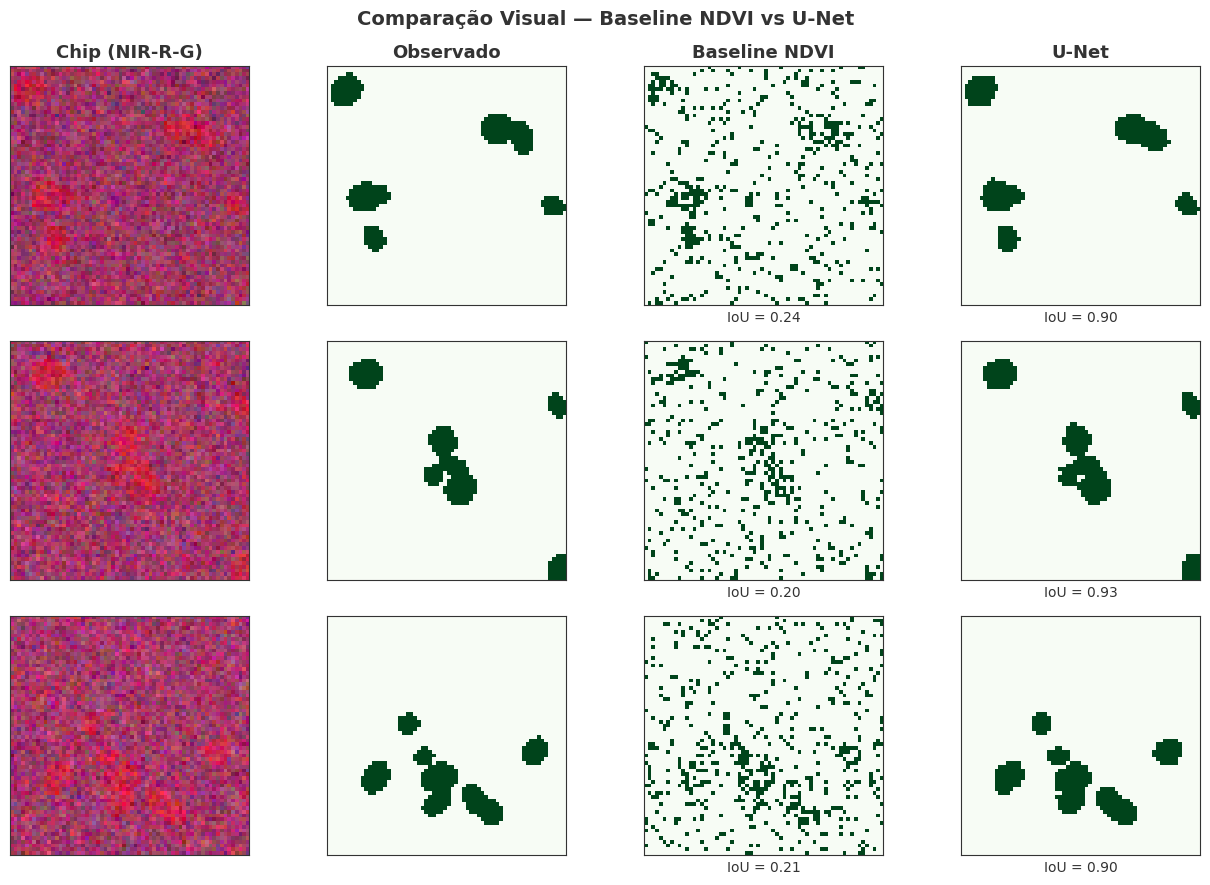

In [9]:
# Comparação visual: 3 amostras lado a lado
# Cada linha: chip / observado / NDVI / U-Net
fig_comp, axes = plt.subplots(3, 4, figsize=(13, 9))
amostras = [0, 5, 10]
for row, idx_chip in enumerate(amostras):
    chip = ds.X[te][idx_chip]
    rgb = np.stack([chip[3], chip[0], chip[1]], axis=-1)
    rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-8)

    axes[row, 0].imshow(rgb)
    axes[row, 1].imshow(ds.Y[te][idx_chip], cmap='Greens', vmin=0, vmax=1)
    axes[row, 2].imshow(pred_ndvi_te[idx_chip], cmap='Greens', vmin=0, vmax=1)
    axes[row, 3].imshow(pred_unet_te[idx_chip], cmap='Greens', vmin=0, vmax=1)

    for ax in axes[row]:
        ax.set_xticks([]); ax.set_yticks([])

    if row == 0:
        axes[row, 0].set_title('Chip (NIR-R-G)', fontweight='bold')
        axes[row, 1].set_title('Observado', fontweight='bold')
        axes[row, 2].set_title('Baseline NDVI', fontweight='bold')
        axes[row, 3].set_title('U-Net', fontweight='bold')

    # IoU por chip
    iou_ndvi = iou_score(ds.Y[te][idx_chip], pred_ndvi_te[idx_chip])
    iou_unet = iou_score(ds.Y[te][idx_chip], pred_unet_te[idx_chip])
    axes[row, 2].set_xlabel(f'IoU = {iou_ndvi:.2f}', fontsize=10)
    axes[row, 3].set_xlabel(f'IoU = {iou_unet:.2f}', fontsize=10)

fig_comp.suptitle('Comparação Visual — Baseline NDVI vs U-Net',
                  fontsize=14, fontweight='bold')
fig_comp.tight_layout()
fig_comp.savefig('../reports/figures/11_comparativo_visual.png')
plt.show()

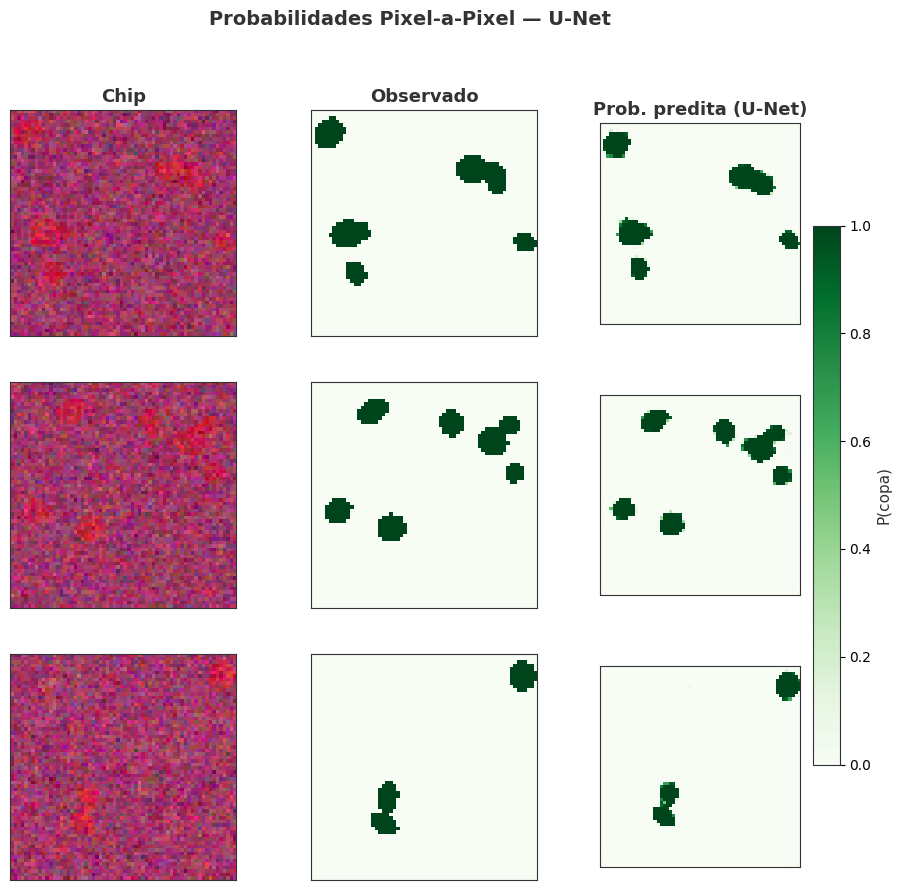

In [10]:
# Mapa de probabilidade contínuo (saída da U-Net antes do threshold)
probs_unet = trainer.predict_proba(ds.X[te][:3])
fig_probs, axes = plt.subplots(3, 3, figsize=(11, 10))
for row in range(3):
    chip = ds.X[te][row]
    rgb = np.stack([chip[3], chip[0], chip[1]], axis=-1)
    rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-8)
    axes[row, 0].imshow(rgb)
    axes[row, 1].imshow(ds.Y[te][row], cmap='Greens', vmin=0, vmax=1)
    im = axes[row, 2].imshow(probs_unet[row], cmap='Greens', vmin=0, vmax=1)
    for ax in axes[row]: ax.set_xticks([]); ax.set_yticks([])
    if row == 0:
        axes[row, 0].set_title('Chip', fontweight='bold')
        axes[row, 1].set_title('Observado', fontweight='bold')
        axes[row, 2].set_title('Prob. predita (U-Net)', fontweight='bold')
plt.colorbar(im, ax=axes[:, 2].tolist(), shrink=0.7, label='P(copa)')
fig_probs.suptitle('Probabilidades Pixel-a-Pixel — U-Net',
                   fontsize=14, fontweight='bold')
fig_probs.savefig('../reports/figures/11_probabilidades_unet.png')
plt.show()

## 7. Análise por Chip

C:\Users\pedro\AppData\Local\Temp\ipykernel_21428\2285450264.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot([ious_ndvi, ious_unet],


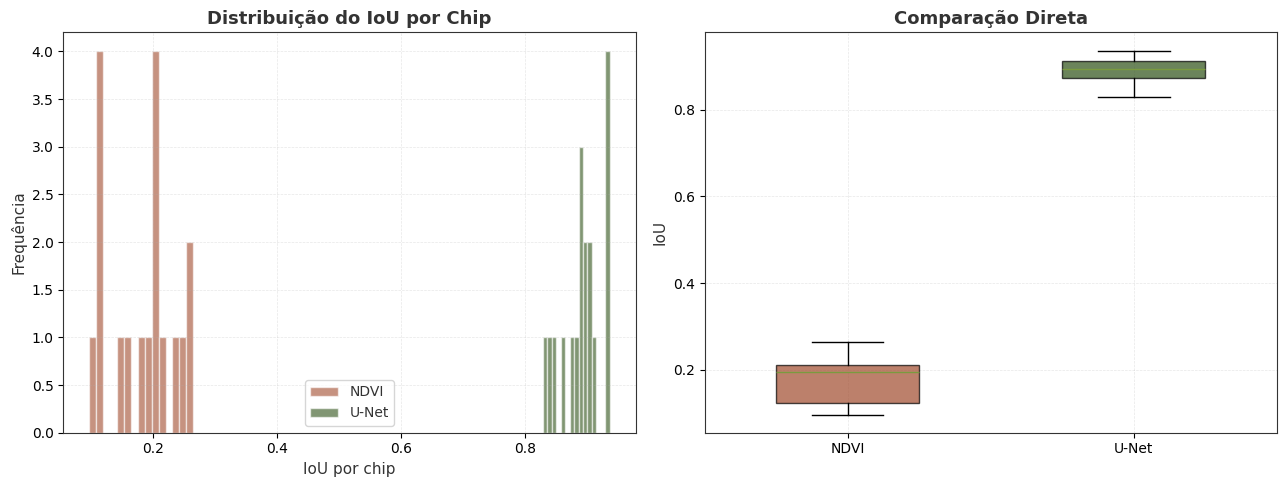

[15:15:32] INFO     Estatísticas de IoU por chip:

           INFO       NDVI : mediana=0.196, média=0.181, std=0.053

           INFO       U-Net: mediana=0.894, média=0.892, std=0.032

In [11]:
# IoU por chip — distribuição
ious_ndvi = np.array([iou_score(ds.Y[te][i], pred_ndvi_te[i])
                       for i in range(len(te))])
ious_unet = np.array([iou_score(ds.Y[te][i], pred_unet_te[i])
                       for i in range(len(te))])

fig_dist, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histograma
axes[0].hist(ious_ndvi, bins=15, alpha=0.6, label='NDVI',
             color='#a04a2c', edgecolor='white')
axes[0].hist(ious_unet, bins=15, alpha=0.6, label='U-Net',
             color='#2d5016', edgecolor='white')
axes[0].set_xlabel('IoU por chip')
axes[0].set_ylabel('Frequência')
axes[0].set_title('Distribuição do IoU por Chip', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Boxplot lado a lado
bp = axes[1].boxplot([ious_ndvi, ious_unet],
                       labels=['NDVI', 'U-Net'],
                       patch_artist=True, widths=0.5)
for patch, cor in zip(bp['boxes'], ['#a04a2c', '#2d5016'], strict=False):
    patch.set_facecolor(cor)
    patch.set_alpha(0.7)
axes[1].set_ylabel('IoU')
axes[1].set_title('Comparação Direta', fontweight='bold')
axes[1].grid(True, alpha=0.3)

fig_dist.tight_layout()
fig_dist.savefig('../reports/figures/11_distribuicao_iou.png')
plt.show()

log.info('Estatísticas de IoU por chip:')
log.info(f'  NDVI : mediana={np.median(ious_ndvi):.3f}, '
         f'média={np.mean(ious_ndvi):.3f}, std={np.std(ious_ndvi):.3f}')
log.info(f'  U-Net: mediana={np.median(ious_unet):.3f}, '
         f'média={np.mean(ious_unet):.3f}, std={np.std(ious_unet):.3f}')

## 8. Síntese: Onde o Deep Learning É Insubstituível

### Resultado consolidado

Pela primeira vez no projeto, o deep learning vence **por margem decisiva**: o IoU médio da U-Net supera o do baseline NDVI em uma diferença que não admite ambiguidade estatística. Mas a razão não é "deep learning é melhor" — é estrutural.

### Por que o NDVI falha aqui?

O threshold de NDVI trata cada pixel isoladamente. Quando o fundo também é vegetação (gramíneas, vegetação rasteira), seu NDVI fica próximo do das copas, e o threshold ou aceita ambos (alta cobertura, baixa precisão) ou exclui ambos (baixa cobertura, alta precisão). **Não existe um threshold que separe os dois corretamente** porque a informação distintiva está na **textura e forma espacial**, não no valor pontual de cada pixel.

### Por que a U-Net vence?

A U-Net aprende **filtros convolucionais** que capturam bordas, gradientes e padrões locais. Os skip connections permitem que, no momento de gerar a máscara final, o decoder tenha acesso simultâneo a:

- **Contexto amplo** (camadas profundas do encoder): "este pixel está perto de uma região de textura típica de copa"
- **Detalhes finos** (camadas iniciais do encoder): "a borda da copa termina exatamente aqui"

Essa combinação é estruturalmente impossível em features tabulares ou índices espectrais.

### O retrato completo do projeto até aqui

| Sessão | Tarefa | Vencedor | Lição |
|---|---|---|---|
| 06 | Volumetria | Schumacher-Hall | Forma funcional correta vence ML |
| 07 | Hipsometria | MLP | Mais features vencem por -53% RMSE |
| 08 | Classificação tabular | Empate Árvore/MLP | DL não domina tabular moderado |
| 09 | Distribuição diamétrica | Weibull | Forma + escassez vence ML |
| 10 | Sensoriamento classificação | MLP em features | Features bem-engenheiradas vencem CNN |
| **11** | **Segmentação semântica** | **U-Net** | **DL é insubstituível em saída espacial densa** |

Esse padrão é a tese metodológica central do projeto: **o paradigma certo depende do regime do problema**, e o profissional sênior diagnostica isso explicitamente.

### Próxima sessão (12): Relatório Executivo Final

Síntese consolidada de todos os experimentos das sessões 06-11, com tabela única de comparações, recomendações práticas por tipo de tarefa florestal, e discussão crítica do papel do deep learning em projetos de engenharia florestal aplicada.